In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

## 📊 Descripción de variables

El dataset contiene información sobre hábitos musicales y salud mental de los participantes.

### 🧍 Datos generales
- **Age:** Edad del participante.
- **Primary streaming service:** Plataforma principal donde escucha música (Spotify, YouTube Music, etc.).
- **Hours per day:** Número de horas que escucha música al día.
- **While working:** Indica si escucha música mientras trabaja (Yes/No).

### 🎼 Relación con la música
- **Instrumentalist:** Si toca algún instrumento musical.
- **Composer:** Si compone música.
- **Fav genre:** Género musical favorito.
- **Exploratory:** Si le gusta explorar nueva música.
- **Foreign languages:** Si escucha música en otros idiomas.
- **BPM:** Ritmo de la música (beats per minute).

### 🎧 Frecuencia por género
Indican qué tan seguido escucha cada género:
- Frequency [Classical]
- Frequency [Country]
- Frequency [EDM]
- Frequency [Folk]
- Frequency [Gospel]
- Frequency [Hip hop]
- Frequency [Jazz]
- Frequency [K pop]
- Frequency [Latin]
- Frequency [Lofi]
- Frequency [Metal]
- Frequency [Pop]
- Frequency [R&B]
- Frequency [Rap]
- Frequency [Rock]
- Frequency [Video game music]

Los valores representan:
- Never (Nunca)
- Rarely (Rara vez)
- Sometimes (A veces)
- Very frequently (Muy frecuentemente)

### 🧠 Salud mental
- **Anxiety:** Nivel de ansiedad (escala numérica).
- **Depression:** Nivel de depresión.
- **Insomnia:** Nivel de insomnio.
- **OCD:** Nivel de trastorno obsesivo-compulsivo.

### 🎵 Percepción de la música
- **Music effects:** Efecto percibido de la música (Improve, No effect, etc.).

In [2]:
df = pd.read_csv("mxmh_survey_results.csv")
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [3]:
df.describe()

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,736.000000,6.290000e+02,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,1.589948e+06,5.837636,4.796196,3.738451,2.637228
std,12.054970,3.028199,3.987261e+07,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


In [4]:
df.isnull().sum()

Timestamp                         0
Age                               1
Primary streaming service         1
Hours per day                     0
While working                     3
Instrumentalist                   4
Composer                          1
Fav genre                         0
Exploratory                       0
Foreign languages                 4
BPM                             107
Frequency [Classical]             0
Frequency [Country]               0
Frequency [EDM]                   0
Frequency [Folk]                  0
Frequency [Gospel]                0
Frequency [Hip hop]               0
Frequency [Jazz]                  0
Frequency [K pop]                 0
Frequency [Latin]                 0
Frequency [Lofi]                  0
Frequency [Metal]                 0
Frequency [Pop]                   0
Frequency [R&B]                   0
Frequency [Rap]                   0
Frequency [Rock]                  0
Frequency [Video game music]      0
Anxiety                     

In [5]:
# Copia de seguridad
df_clean = df.copy()

# Eliminar columnas poco útiles
df_clean = df_clean.drop(columns=["Timestamp", "Permissions"], errors='ignore')

# Convertir numéricas
cols_numeric = ["Age", "Hours per day", "BPM", "Anxiety", "Depression", "Insomnia", "OCD"]

for col in cols_numeric:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Manejo de nulos

# BPM -> demasiados nulos → eliminar columna
df_clean = df_clean.drop(columns=["BPM"])

# Rellenar categóricas con "Unknown"
cols_cat = df_clean.select_dtypes(include="object").columns
df_clean[cols_cat] = df_clean[cols_cat].fillna("Unknown")

# Eliminar filas con valores críticos nulos
df_clean = df_clean.dropna(subset=["Age", "Hours per day"])

df_clean.isnull().sum()

Age                             0
Primary streaming service       0
Hours per day                   0
While working                   0
Instrumentalist                 0
Composer                        0
Fav genre                       0
Exploratory                     0
Foreign languages               0
Frequency [Classical]           0
Frequency [Country]             0
Frequency [EDM]                 0
Frequency [Folk]                0
Frequency [Gospel]              0
Frequency [Hip hop]             0
Frequency [Jazz]                0
Frequency [K pop]               0
Frequency [Latin]               0
Frequency [Lofi]                0
Frequency [Metal]               0
Frequency [Pop]                 0
Frequency [R&B]                 0
Frequency [Rap]                 0
Frequency [Rock]                0
Frequency [Video game music]    0
Anxiety                         0
Depression                      0
Insomnia                        0
OCD                             0
Music effects 

### Distribución de ansiedad, depresión, insomnio y OCD

Se observa cómo se distribuyen los valores de las variables de salud mental.

En general:
- La mayoría de los valores se concentran en niveles bajos a medios.
- Existen algunos valores altos, lo que indica que ciertos participantes presentan niveles elevados de estas condiciones.
- Esto sugiere que la muestra incluye tanto personas con bajo como alto nivel de afectación emocional.

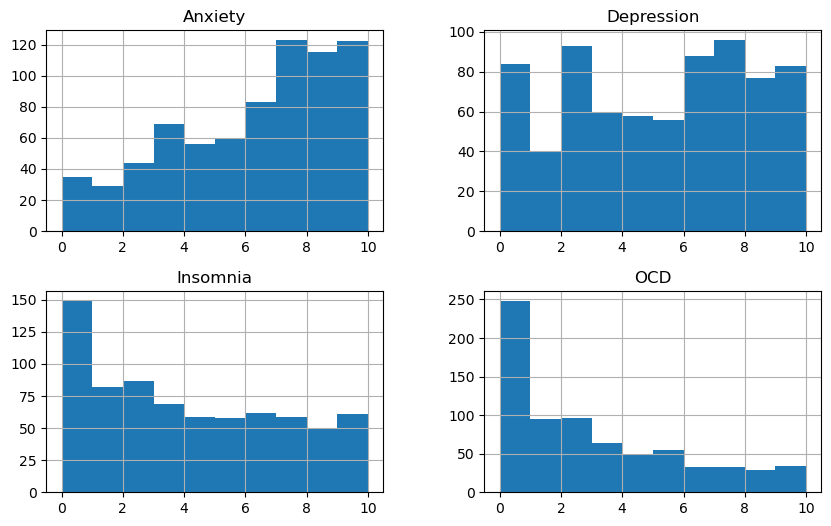

In [6]:
mental_cols = ["Anxiety", "Depression", "Insomnia", "OCD"]

df_clean[mental_cols].hist(figsize=(10,6))
plt.show()

### Detección de valores atípicos (outliers)

El boxplot muestra la distribución de la edad y las horas de consumo de música.

Se observa que:
- Existen valores extremos en las horas de escucha, lo que indica que algunos usuarios escuchan música durante muchas horas al día.
- La edad presenta menor variabilidad, aunque puede haber algunos valores fuera de lo común.

Esto es importante ya que los outliers pueden influir en los resultados del análisis.

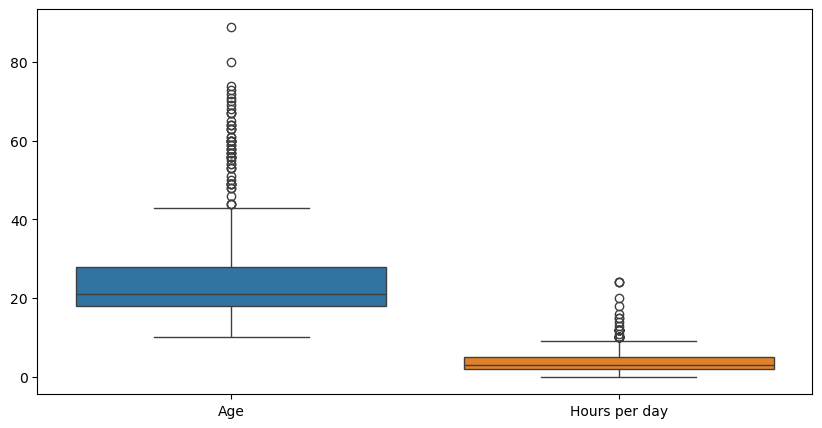

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_clean[["Age", "Hours per day"]])
plt.show()

### Plataforma de streaming más utilizada

Se observa la frecuencia de uso de cada servicio de música.

Los resultados muestran que:
- Algunas plataformas dominan claramente (como Spotify o YouTube).
- Esto indica una preferencia fuerte por ciertos servicios dentro de la muestra.

Este dato puede ser relevante si el tipo de plataforma influye en los hábitos musicales.

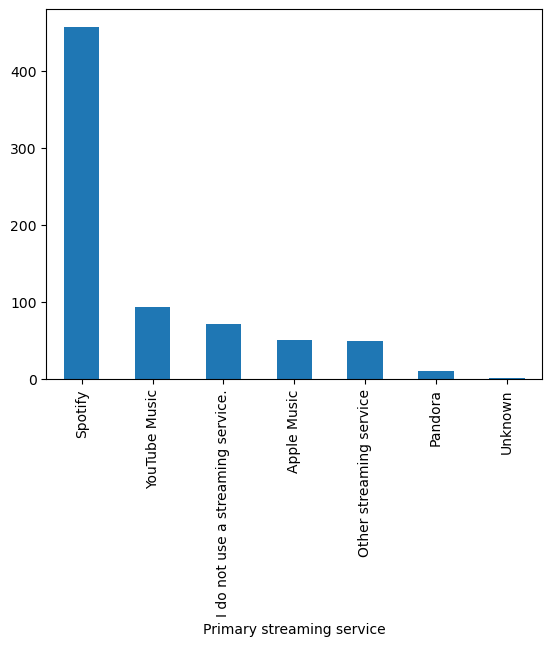

In [8]:
plt.figure()
df_clean["Primary streaming service"].value_counts().plot(kind="bar")
plt.show()

### Relación entre horas de música y salud mental

Las gráficas de dispersión permiten observar la relación entre el tiempo de escucha y variables como ansiedad o depresión.

Se observa que:
- No existe una relación completamente lineal.
- Sin embargo, algunos usuarios con mayor consumo presentan niveles elevados de ansiedad o depresión.

Esto sugiere que el tiempo de escucha podría estar relacionado con el estado emocional, aunque no es el único factor.

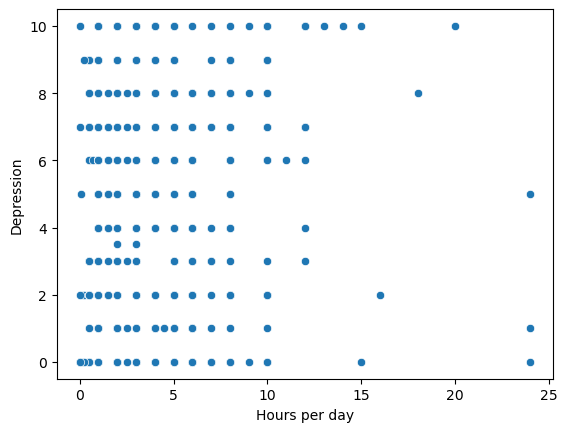

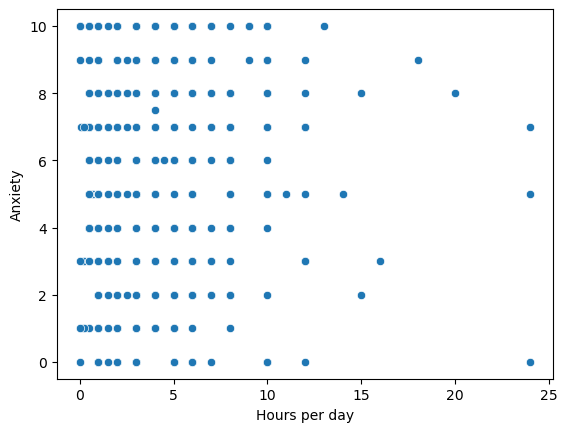

In [9]:
sns.scatterplot(x="Hours per day", y="Depression", data=df_clean)
plt.show()

sns.scatterplot(x="Hours per day", y="Anxiety", data=df_clean)
plt.show()

### Relación entre género musical y ansiedad

El boxplot muestra cómo varía la ansiedad según el género musical favorito.

Se observa que:
- Algunos géneros presentan mayor variabilidad en los niveles de ansiedad.
- Otros géneros tienen valores más concentrados.

Esto sugiere que el tipo de música podría estar asociado con diferentes estados emocionales.

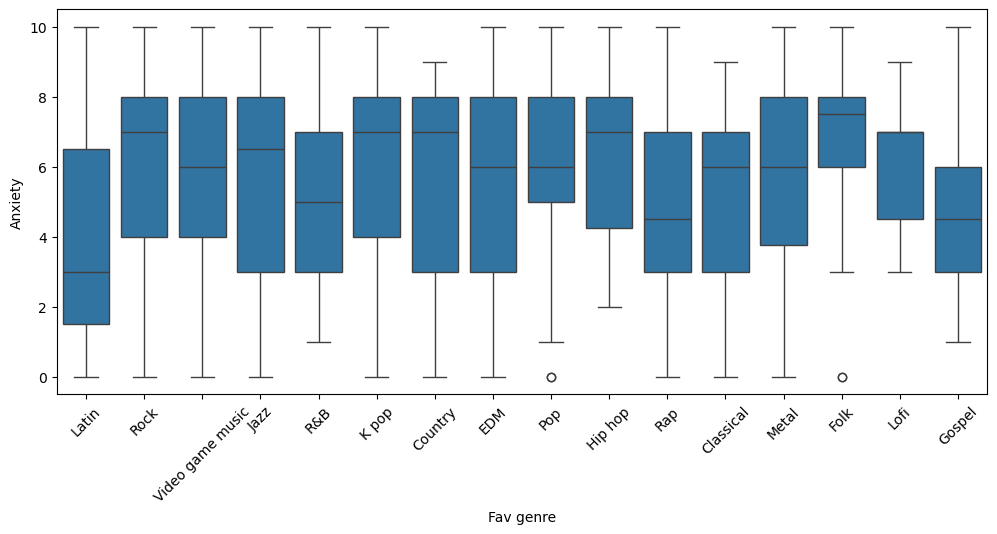

In [10]:
plt.figure(figsize=(12,5))
sns.boxplot(x="Fav genre", y="Anxiety", data=df_clean)
plt.xticks(rotation=45)
plt.show()

### Correlación entre variables

La matriz de correlación muestra la relación entre variables numéricas.

Se observa que:
- Existe una fuerte relación entre ansiedad y depresión.
- Algunas variables presentan correlaciones moderadas.
- Las horas de música tienen una relación débil con las variables mentales.

Esto indica que la salud mental está más relacionada entre sí que con el consumo de música directamente.

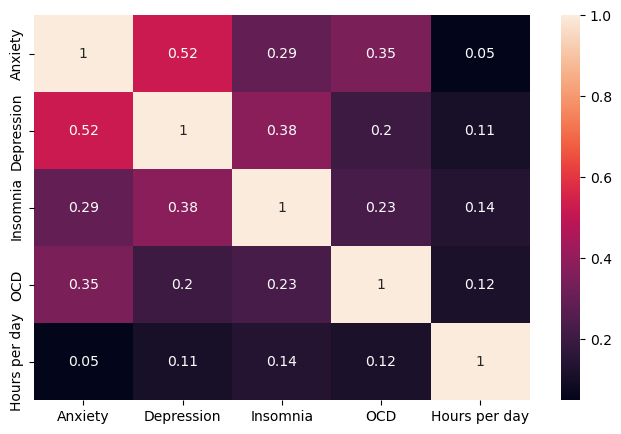

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df_clean[mental_cols + ["Hours per day"]].corr(), annot=True)
plt.show()

### Géneros musicales más populares

La gráfica muestra los géneros favoritos de los participantes.

Se observa que:
- Algunos géneros destacan sobre otros, lo que refleja tendencias musicales claras.
- Esto puede influir en la relación con la salud mental, ya que diferentes géneros pueden generar distintas emociones.

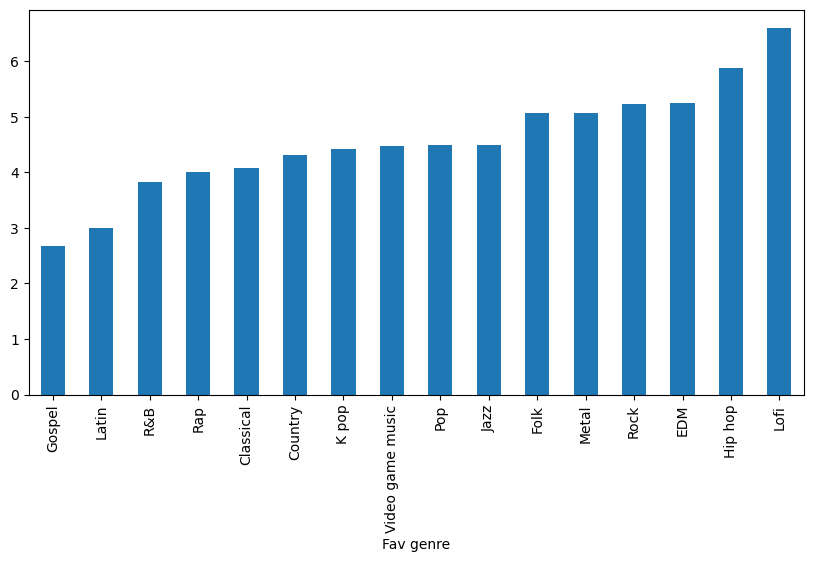

In [12]:
df_clean.groupby("Fav genre")["Depression"].mean().sort_values().plot(kind="bar", figsize=(10,5))
plt.show()

### Efecto de la música en la ansiedad

Se observa cómo cambia la ansiedad según el efecto percibido de la música.

Se identifica que:
- Las personas que indican que la música mejora su estado presentan ciertos patrones.
- Aquellos que no perciben efecto pueden tener niveles distintos.

Esto sugiere que la percepción personal de la música es importante.

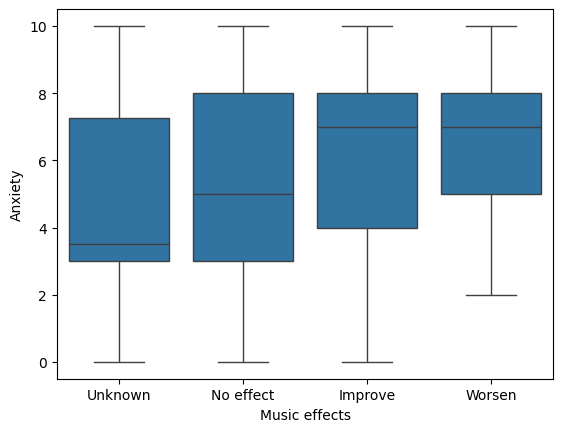

In [13]:
sns.boxplot(x="Music effects", y="Anxiety", data=df_clean)
plt.show()

### Escuchar música mientras se trabaja

Se analiza la ansiedad en función de si la persona escucha música mientras trabaja.

Se observa que:
- Puede haber diferencias entre quienes escuchan música y quienes no.
- Esto podría indicar que la música influye en la concentración o el estado emocional durante el trabajo.

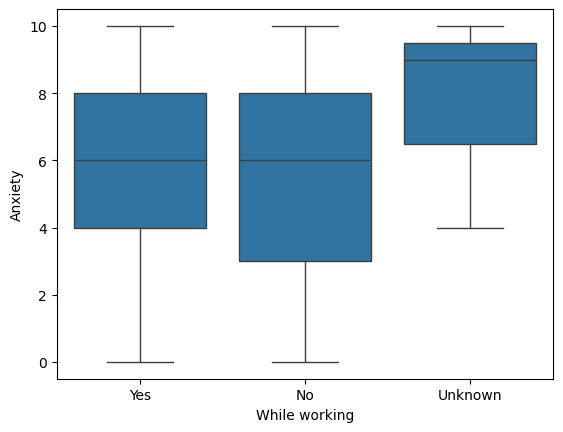

In [14]:
sns.boxplot(x="While working", y="Anxiety", data=df_clean)
plt.show()

In [15]:
freq_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Very frequently": 3
}

freq_cols = [col for col in df_clean.columns if "Frequency" in col]

for col in freq_cols:
    df_clean[col] = df_clean[col].map(freq_map)

### Relación entre frecuencia de géneros y salud mental

Se observa la correlación entre la frecuencia de escucha de distintos géneros y variables como ansiedad o depresión.

Se identifica que:
- Algunos géneros presentan correlaciones positivas o negativas.
- Esto sugiere que ciertos estilos musicales podrían estar asociados con distintos estados emocionales.

Este análisis es clave para entender patrones más profundos en los datos.

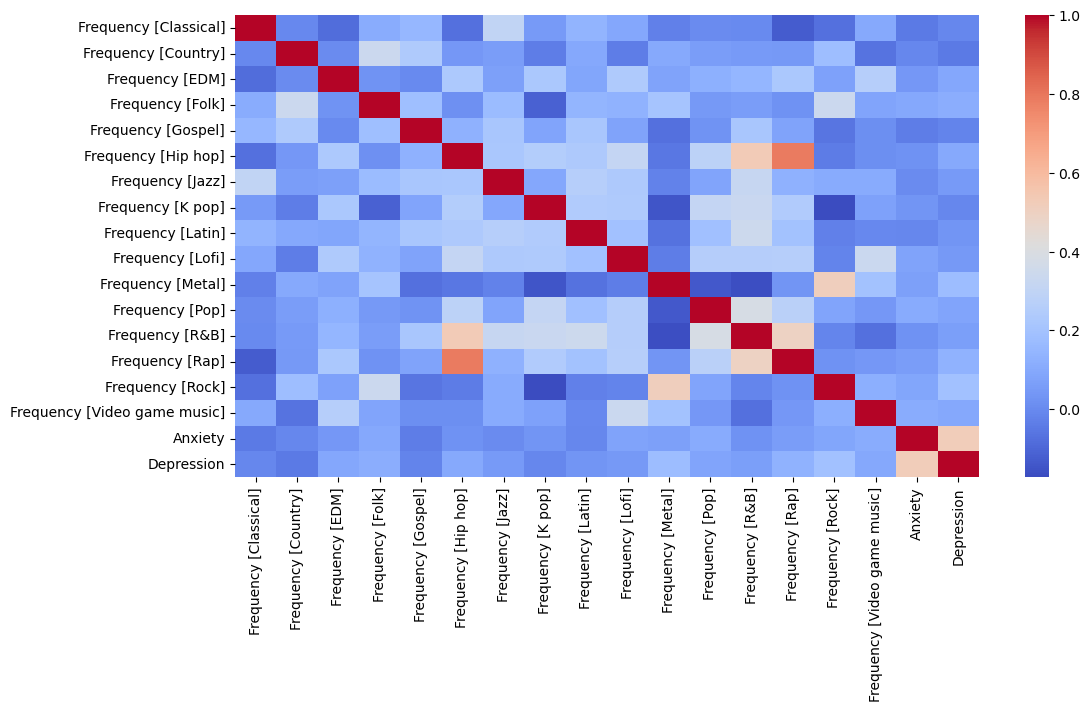

In [16]:
plt.figure(figsize=(12,6))
sns.heatmap(df_clean[freq_cols + ["Anxiety", "Depression"]].corr(), cmap="coolwarm")
plt.show()

# Fase 2

##  Definición del problema

El objetivo de esta fase es construir un modelo predictivo que permita estimar el nivel de ansiedad de un individuo (variable continua de 0 a 10) a partir de sus hábitos de consumo musical y características personales.

Dado que la variable objetivo es numérica y continua, este problema se aborda como un problema de **regresión**.

Este enfoque permitirá analizar qué variables influyen más en la ansiedad y evaluar la capacidad predictiva de distintos modelos de machine learning.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Preprocesamiento de datos

En esta sección se aplican transformaciones a los datos con base en los hallazgos del EDA:

- Se eliminan valores atípicos en la variable "Hours per day", ya que se identificaron valores poco realistas (mayores a 10 horas).
- Se convierten variables categóricas a formato numérico mediante One-Hot Encoding.
- Se crean nuevas variables (feature engineering) para enriquecer el modelo.

In [18]:
df_clean = df_clean[df_clean["Hours per day"] <= 10]

# Copia base para la fase 2, ya con las frecuencias convertidas a números
df_model = df_clean.copy()

# Suma total de frecuencia musical
freq_cols = [col for col in df_model.columns if "Frequency" in col]
df_model["total_music_freq"] = df_model[freq_cols].sum(axis=1)

# Usuario que escucha mucha música
df_model["high_listener"] = (df_model["Hours per day"] > 5).astype(int)

Se aplica One-Hot Encoding a las variables categóricas nominales para convertirlas en variables numéricas utilizables por los modelos.

In [19]:
df_model = pd.get_dummies(df_model, drop_first=True)
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 715 entries, 0 to 735
Data columns (total 57 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Age                                                          715 non-null    float64
 1   Hours per day                                                715 non-null    float64
 2   Frequency [Classical]                                        715 non-null    int64  
 3   Frequency [Country]                                          715 non-null    int64  
 4   Frequency [EDM]                                              715 non-null    int64  
 5   Frequency [Folk]                                             715 non-null    int64  
 6   Frequency [Gospel]                                           715 non-null    int64  
 7   Frequency [Hip hop]                                          715 non-null    int64  


Se define la variable objetivo (y) como el nivel de ansiedad y las variables predictoras (X) como el resto de variables del dataset.

In [20]:
X = df_model.drop("Anxiety", axis=1)
y = df_model["Anxiety"]

Se divide el dataset en entrenamiento (80%) y prueba (20%). Se utiliza un random_state fijo para garantizar la reproducibilidad.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

## Modelo 1: Regresión Lineal

La regresión lineal es un modelo simple que asume una relación lineal entre las variables independientes y la variable objetivo. Se utiliza como línea base para comparar con modelos más complejos.

In [23]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

Se utilizan las métricas RMSE, MAE y R² para evaluar el desempeño del modelo.

In [24]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

Linear Regression
RMSE: 2.4043192830309343
MAE: 1.8975079810492663
R2: 0.2569928402991095


## Modelo 2: Random Forest

Random Forest es un modelo basado en árboles que permite capturar relaciones no lineales entre variables. Es robusto ante outliers y no requiere escalado de variables.

In [25]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

In [26]:
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5)

print("Cross-validation R2:", cv_scores.mean())

Cross-validation R2: 0.32388694348203806


Se utilizan las métricas RMSE, MAE y R² para evaluar el desempeño del modelo.

In [27]:
y_pred_rf = best_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)

Random Forest
RMSE: 2.274646210867832
MAE: 1.8216783216783217
R2: 0.334977352881095


Se comparan los modelos utilizando las métricas principales para determinar cuál ofrece mejor desempeño.

In [28]:
results = pd.DataFrame({
    "Modelo": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "MAE": [mae_lr, mae_rf],
    "R2": [r2_lr, r2_rf]
})

results

,Modelo,RMSE,MAE,R2
0,Linear Regression,2.404319,1.897508,0.256993
1,Random Forest,2.274646,1.821678,0.334977


Se analiza la diferencia entre el desempeño en entrenamiento y prueba para detectar overfitting.

In [29]:
train_score = best_rf.score(X_train, y_train)
test_score = best_rf.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.9077024295299426
Test R2: 0.334977352881095


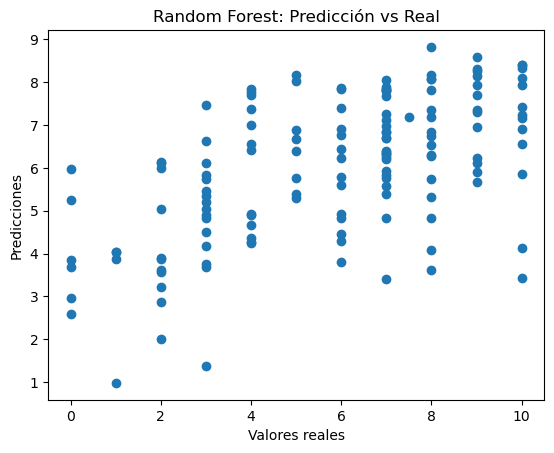

In [30]:
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Random Forest: Predicción vs Real")
plt.show()

Se analiza la importancia de variables para identificar cuáles influyen más en la predicción.

In [31]:
importances = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
18,Depression,0.298981
20,OCD,0.094821
19,Insomnia,0.065515
0,Age,0.061753
21,total_music_freq,0.042957
1,Hours per day,0.034744
11,Frequency [Lofi],0.027185
12,Frequency [Metal],0.021659
5,Frequency [Folk],0.020189
14,Frequency [R&B],0.019952


## Conclusión

El modelo Random Forest mostró un mejor desempeño en comparación con la regresión lineal, lo cual sugiere que las relaciones entre las variables no son completamente lineales.

Las variables más importantes incluyen hábitos de consumo musical y características individuales, lo cual coincide con los hallazgos del análisis exploratorio.

El modelo seleccionado para este problema sería Random Forest, debido a su mayor capacidad predictiva y robustez.

Sin embargo, el modelo presenta limitaciones, como la posible influencia de datos auto-reportados y la ausencia de variables externas relevantes.

En futuras iteraciones se podría mejorar el modelo incorporando más datos, nuevas variables o probando modelos más avanzados.